# WINE QUALITY PREDICTION
**`Task: Predict wine quality score.`** 
### Focus Areas: 
* `Correlation analysis`
* `Feature scaling`
* `Compare Random Forest, SVM, and KNN` 
* `Evaluation Metrics: Accuracy, Macro F1-score.`

**`importing Relevant Libraries`**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier

## EXPLORATORY DATA ANALYSIS

In [5]:
data= pd.read_csv("QualityPrediction.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
data.shape

(1599, 12)

In [8]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [9]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [10]:
data['quality'].unique()
data['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

`Splitting the data into training and testing sets`

In [11]:
# We use 80% for training and 20% for testing
train_data, test_data = train_test_split(data, test_size=0.2, random_state=20)
print('The size of training data is: {}\nThe size of testing data is: {}'.format(len(train_data), len(test_data)))

The size of training data is: 1279
The size of testing data is: 320


In [12]:
# checking the first five train_data rows
train_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
605,8.3,0.60,0.13,2.6,0.085,6.0,24.0,0.99840,3.31,0.59,9.2,6
392,9.5,0.37,0.52,2.0,0.082,6.0,26.0,0.99800,3.18,0.51,9.5,5
849,6.4,0.63,0.21,1.6,0.080,12.0,32.0,0.99689,3.58,0.66,9.8,5
1418,7.8,0.53,0.01,1.6,0.077,3.0,19.0,0.99500,3.16,0.46,9.8,5
459,11.6,0.58,0.66,2.2,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3


## Creating the copy of the train dataset

In [13]:
train_copy=train_data.copy

In [14]:
# checking the first five train_data rows
train_copy

<bound method NDFrame.copy of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
605             8.3              0.60         0.13             2.6      0.085   
392             9.5              0.37         0.52             2.0      0.082   
849             6.4              0.63         0.21             1.6      0.080   
1418            7.8              0.53         0.01             1.6      0.077   
459            11.6              0.58         0.66             2.2      0.074   
...             ...               ...          ...             ...        ...   
924             8.6              0.47         0.27             2.3      0.055   
1247            7.4              0.55         0.19             1.8      0.082   
271            11.5              0.18         0.51             4.0      0.104   
474            10.5              0.28         0.51             1.7      0.080   
1379            7.5              0.57         0.02             2.6      0.077  

In [15]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1279 entries, 605 to 1379
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1279 non-null   float64
 1   volatile acidity      1279 non-null   float64
 2   citric acid           1279 non-null   float64
 3   residual sugar        1279 non-null   float64
 4   chlorides             1279 non-null   float64
 5   free sulfur dioxide   1279 non-null   float64
 6   total sulfur dioxide  1279 non-null   float64
 7   density               1279 non-null   float64
 8   pH                    1279 non-null   float64
 9   sulphates             1279 non-null   float64
 10  alcohol               1279 non-null   float64
 11  quality               1279 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 129.9 KB


`Checking Summary Statistics`

In [16]:
train_data.shape

(1279, 12)

In [17]:
train_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000,1279.000000
mean,8.285848,0.529003,0.267842,2.535379,0.086453,15.842455,46.505864,0.996714,3.310829,0.657013,10.409030,5.622361
std,1.721028,0.178569,0.193524,1.444648,0.045854,10.590249,32.739920,0.001863,0.154108,0.169121,1.070440,0.816784
min,4.600000,0.120000,0.000000,0.900000,0.034000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997800,3.400000,0.730000,11.083333,6.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,72.000000,278.000000,1.003690,4.010000,2.000000,14.000000,8.000000


In [18]:
train_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1279.0,8.285848,1.721028,4.60000,7.1000,7.9000,9.100000,15.60000
volatile acidity,1279.0,0.529003,0.178569,0.12000,0.3950,0.5200,0.640000,1.58000
citric acid,1279.0,0.267842,0.193524,0.00000,0.0900,0.2500,0.420000,1.00000
residual sugar,1279.0,2.535379,1.444648,0.90000,1.9000,2.2000,2.600000,15.50000
chlorides,1279.0,0.086453,0.045854,0.03400,0.0700,0.0790,0.090000,0.61100
free sulfur dioxide,1279.0,15.842455,10.590249,1.00000,7.0000,13.0000,21.000000,72.00000
total sulfur dioxide,1279.0,46.505864,32.739920,6.00000,22.0000,38.0000,62.000000,278.00000
density,1279.0,0.996714,0.001863,0.99007,0.9956,0.9967,0.997800,1.00369
pH,1279.0,3.310829,0.154108,2.74000,3.2100,3.3100,3.400000,4.01000
sulphates,1279.0,0.657013,0.169121,0.33000,0.5500,0.6200,0.730000,2.00000


`checking missing values`

In [19]:
train_data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

`Checking correlation between features`

In [20]:
cor = train_data.corr()

<Axes: >

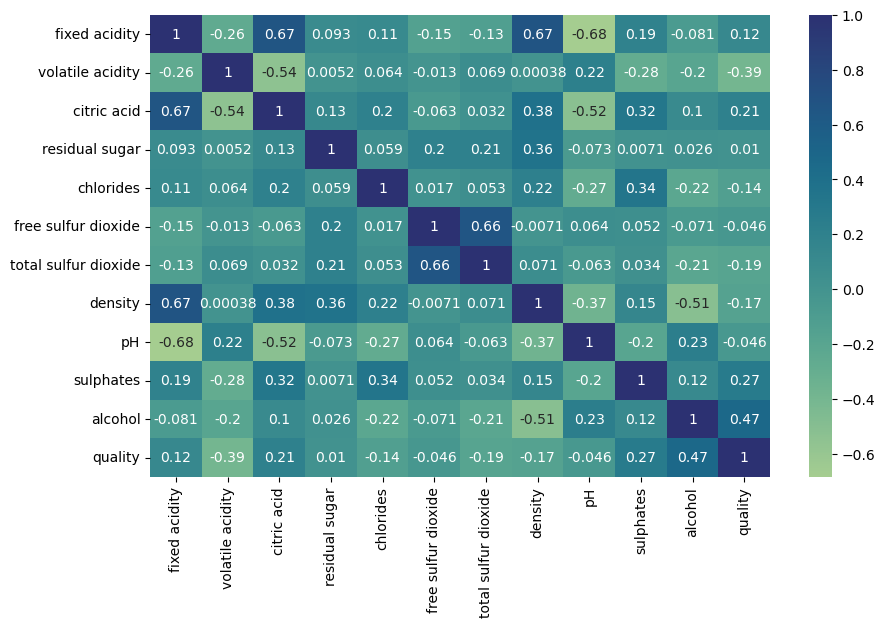

In [21]:
plt.figure(figsize=(10, 6))
sns.heatmap(cor, annot=True, cmap='crest')

* We notice a positive correlation betweem fixed acidity and citric acid (0.67), fixed acidity and density(0.67)
* Negative correlation between fixed acidity and pH (-0.68), volatil acidity and citric acid (-0.54), pH and citric acid (-0.52), alcohol and density (-0.51).

`More Exploration`

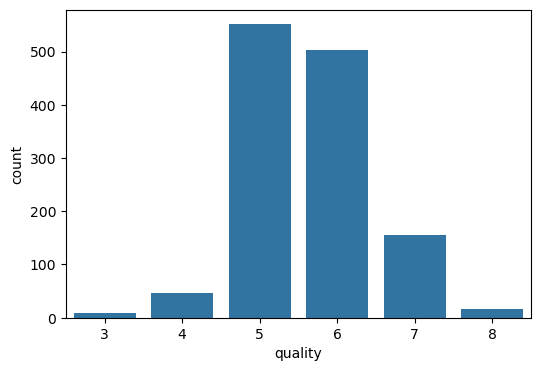

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(train_data, x='quality')
plt.show()

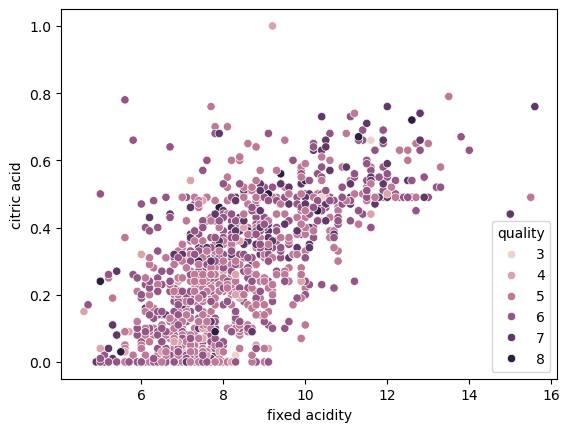

In [23]:
# Checking the relationship between fixed acidity and citric acid
sns.scatterplot(data=train_data, x='fixed acidity', y='citric acid', hue='quality')
plt.show()

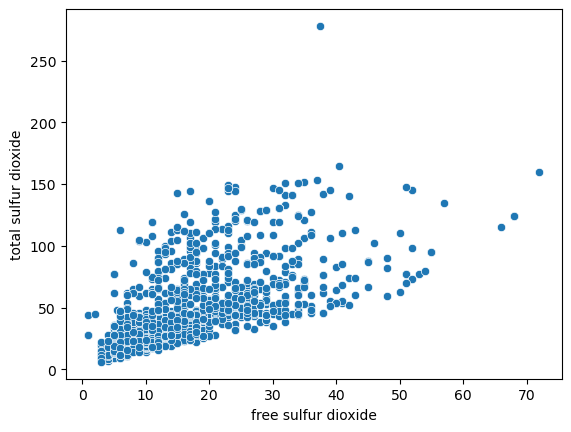

In [80]:
# Checking the relationship between free  and total sulfur dioxide
sns.scatterplot(data=train_data, x='free sulfur dioxide', y='total sulfur dioxide')
plt.show()

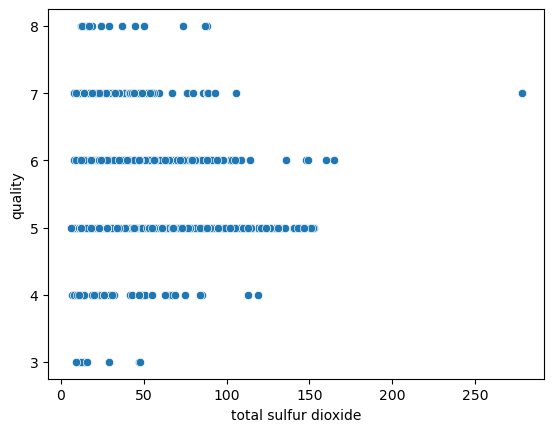

In [84]:
# Checking the relationship between total sulfur dioxide and quality
sns.scatterplot(data=train_data, x='total sulfur dioxide', y='quality')
plt.show()

In [24]:
train_data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

`plotting histogram for all the columns`

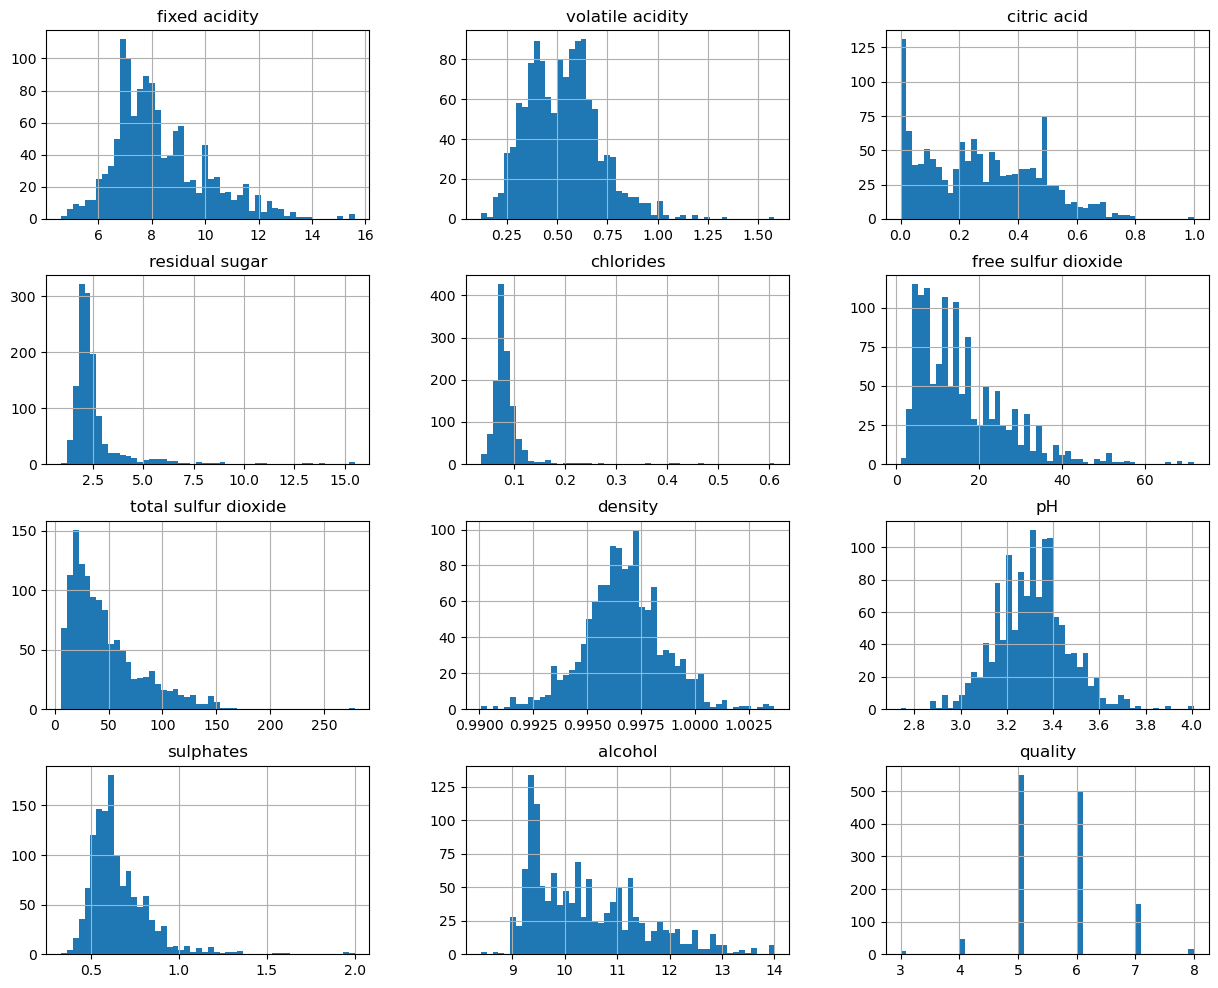

In [25]:
train_data.hist(figsize=(15,12), bins= 50)
plt.show()

## Data Processing

* Preparing the data for modelling
* Feature Scaling

In [26]:
train_data["good_quality"] = [1 if i >=7 else 0 for i in train_data["quality"]]
train_data["good_quality"].value_counts(normalize=True)

good_quality
0    0.866302
1    0.133698
Name: proportion, dtype: float64

<Axes: xlabel='good_quality', ylabel='count'>

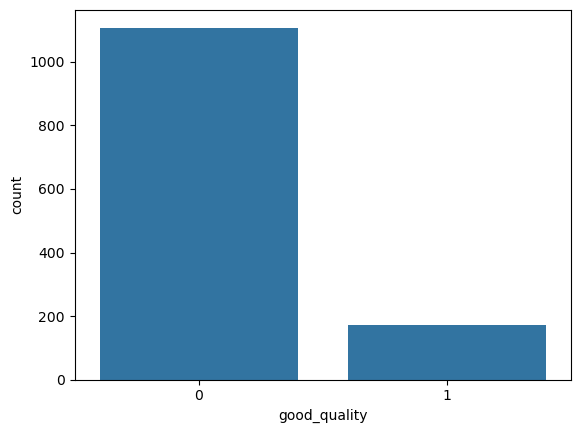

In [27]:
sns.countplot(train_data, x='good_quality')

In [28]:
# Use LabelEncoder to scale the label column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [29]:
X_train= train_data.drop(['quality', "good_quality"], axis=1)
y_train=le.fit_transform(train_data["good_quality"])

In [30]:
print(y_train)
print(y_train.shape)
np.unique(y_train)

[0 0 0 ... 0 0 0]
(1279,)


array([0, 1])

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipe= Pipeline([('scaler', StandardScaler())])  #Using StandardScaler to scale the features to values between -1 and 1
X_train_pipe= num_pipe.fit_transform(X_train)

In [32]:
X_train_pipe

array([[ 0.00822603,  0.3977436 , -0.71255252, ..., -0.00537996,
        -0.39639994, -1.12991275],
       [ 0.70575665, -0.89077835,  1.30349015, ..., -0.84927213,
        -0.86961942, -0.84954445],
       [-1.09619746,  0.56581168, -0.29900531, ...,  1.74731918,
         0.01766711, -0.56917615],
       ...,
       [ 1.86830768, -1.95520952,  1.25179675, ..., -0.20012431,
         1.85139259, -0.28880785],
       [ 1.28703216, -1.39498259,  1.25179675, ..., -0.71944257,
         1.37817311, -0.94300055],
       [-0.45679439,  0.22967552, -1.28117994, ...,  0.31919396,
        -0.21894263,  0.36538486]], shape=(1279, 11))

## Training a Random Forest Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier

rfr_clf = RandomForestClassifier(
    min_samples_split=2, random_state=42, 
    bootstrap= False, max_depth=None, max_features='log2',n_jobs=-1
)

rfr_clf.fit(X_train_pipe, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


## Evaluating Random Forest Classifier
Let's build 4 functions to display accuracy, F1_score confusion matrix, and classification report.

* Accuracy provide a percentage score of the model's ability to make correct predictions
* Confusion matrix shows the predicted and the actual classes...True Negativse(TN), True Positives(TP), False Negatives(FN), and True Positives(TP).
* Classification report contains all useful metrics such as precision, recall, and f1 score..

In [34]:
# Importing Accuracy, F1_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [35]:
def accuracy(input_data,model,labels):
    """
    Take the input data, model and labels and return accuracy
    
    """
    
    preds = model.predict(input_data)
    acc = accuracy_score(labels,preds)
    
    return acc

def conf_matrix(input_data,model,labels):
    """
    Take the input data, model and labels and return confusion matrix
    
    """
    
    preds = model.predict(input_data)
    cm = confusion_matrix(labels,preds)
    
    return cm
def f1(input_data,model,labels):
    """
    Take the input data, model and labels and return f1_score
    
    """
    
    preds = model.predict(input_data)
    cm = f1_score(labels,preds)
    
    return cm

def class_report(input_data,model,labels):
    """
    Take the input data, model and labels and return Classification report
    
    """
    
    preds = model.predict(input_data)
    report = classification_report(labels,preds)
    report = print(report)
    
    return report

`Accuracy`

In [36]:
accuracy(X_train_pipe, rfr_clf, y_train)

1.0

**The model overfit the dataset**

`Confusion Matrix`

In [37]:
conf_matrix(X_train_pipe, rfr_clf, y_train)

array([[1108,    0],
       [   0,  171]])

`Classification Report`

In [38]:
class_report(X_train_pipe, rfr_clf, y_train)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1108
           1       1.00      1.00      1.00       171

    accuracy                           1.00      1279
   macro avg       1.00      1.00      1.00      1279
weighted avg       1.00      1.00      1.00      1279



**The model Clearly overfit the dataset**

## Improvin Random Forest

In [39]:
# Random forest model parameters

rfr_clf.get_params()

{'bootstrap': False,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'log2',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

We will use GridSearch to find the best hyperparameters that we can use to retrain the model with. By setting the `refit` to `True`, the random forest will be automatically retrained on the dataset with the best hyperparameters. By default, `refit` is True.


In [40]:
# Let's hide warnings

import warnings
warnings.filterwarnings('ignore')

In [41]:
from sklearn.model_selection import GridSearchCV

params_grid = {
    'n_estimators':[100,200,300,500],
    'max_leaf_nodes':list(range(0,10)),
    'min_samples_leaf': [0,1,2,3,4]}

#refit is true by default. The best estimator is trained on the whole dataset 

grid_search = GridSearchCV(RandomForestClassifier(bootstrap=False,class_weight='balanced', n_jobs=-1, max_features='sqrt'), params_grid, verbose=1, cv=3)

grid_search.fit(X_train_pipe, y_train)

Fitting 3 folds for each of 200 candidates, totalling 600 fits


,estimator,"RandomForestC...d', n_jobs=-1)"
,param_grid,"{'max_leaf_nodes': [0, 1, ...], 'min_samples_leaf': [0, 1, ...], 'n_estimators': [100, 200, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [42]:
grid_search.best_params_

{'max_leaf_nodes': 9, 'min_samples_leaf': 1, 'n_estimators': 100}

In [43]:
grid_search.best_estimator_

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,9
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [44]:
rforest_best= grid_search.best_estimator_

## Evaluating Random Forest

In [45]:
accuracy(X_train_pipe, rforest_best, y_train)

0.8232994526974199

In [46]:
conf_matrix(X_train_pipe, rforest_best, y_train)

array([[898, 210],
       [ 16, 155]])

In [47]:
class_report(X_train_pipe, rforest_best, y_train)

              precision    recall  f1-score   support

           0       0.98      0.81      0.89      1108
           1       0.42      0.91      0.58       171

    accuracy                           0.82      1279
   macro avg       0.70      0.86      0.73      1279
weighted avg       0.91      0.82      0.85      1279



## Evaluating the Model on Test Set for Random Forest

In [48]:
test_data['good_quality'] = [1 if i >=6 else 0 for i in test_data['quality']]
test_data['good_quality'].value_counts()

good_quality
1    182
0    138
Name: count, dtype: int64

In [49]:
X_test = test_data.drop(['quality', 'good_quality'], axis=1)
y_test = test_data['good_quality']
X_tested= num_pipe.fit_transform(X_test)
y_tested = le.fit_transform(test_data['good_quality'])

In [50]:
accuracy(X_tested, rforest_best, y_test)

0.68125

In [51]:
conf_matrix(X_tested, rforest_best, y_tested)

array([[131,   7],
       [ 95,  87]])

In [52]:
class_report(X_tested, rforest_best, y_tested)

              precision    recall  f1-score   support

           0       0.58      0.95      0.72       138
           1       0.93      0.48      0.63       182

    accuracy                           0.68       320
   macro avg       0.75      0.71      0.68       320
weighted avg       0.78      0.68      0.67       320



## Training Support Vector Classifier
We are going to train two classifiers: Linear SVC and SVC that we can use different kernels.

In [53]:
from sklearn.svm import LinearSVC, SVC

lin_svc = LinearSVC()
lin_svc.fit(X_train_pipe, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [54]:
poly_svc = SVC(kernel='poly')

poly_svc.fit(X_train_pipe, y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Evaluating Support Vector Classifier

* Let's first check the accuracy on the training. 
For this step since we are trying to find model to improve further, we won't touch test set yet.

In [55]:
# Evaluating for LinearSVC
from sklearn.metrics import accuracy_score

lin_pred = lin_svc.predict(X_train_pipe)

accuracy_score(y_train, lin_pred)

0.8827208756841283

In [56]:
# Evaluating for PolySVC
from sklearn.metrics import accuracy_score

poly_pred = poly_svc.predict(X_train_pipe)

accuracy_score(y_train, poly_pred)

0.9053948397185301

In [57]:
# PolySVC
from sklearn.metrics import confusion_matrix, classification_report

confusion_matrix(y_train, poly_pred)

array([[1099,    9],
       [ 112,   59]])

In [58]:
print(classification_report(y_train, poly_pred))  #PolySVC

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      1108
           1       0.87      0.35      0.49       171

    accuracy                           0.91      1279
   macro avg       0.89      0.67      0.72      1279
weighted avg       0.90      0.91      0.89      1279



## Evaluating the Model on Test Set for SVC

In [59]:
# test_scaled = num_pipe.transform(X_test_pipe)

In [60]:
# test_pred = poly_best.predict(test_scaled)

In [61]:
poly_predict = poly_svc.predict(X_tested)

In [62]:
accuracy_score(poly_predict, y_tested)

0.475

In [63]:
print(classification_report(y_tested, poly_predict))

              precision    recall  f1-score   support

           0       0.45      0.99      0.62       138
           1       0.89      0.09      0.16       182

    accuracy                           0.47       320
   macro avg       0.67      0.54      0.39       320
weighted avg       0.70      0.47      0.36       320



## Training KNN Model

In [64]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier()
kn.fit(X_train_pipe,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [65]:
kn.score(X_train_pipe, y_train)

0.9155590304925724

In [66]:
kn.score(X_tested, y_tested)

0.546875

In [67]:
pred=kn.predict(X_tested)

In [68]:
confusion_matrix(y_tested, pred)

array([[136,   2],
       [143,  39]])

In [69]:
accuracy_score(y_tested, pred)

0.546875

In [75]:
classification_report(y_tested, pred)

'              precision    recall  f1-score   support\n\n           0       0.49      0.99      0.65       138\n           1       0.95      0.21      0.35       182\n\n    accuracy                           0.55       320\n   macro avg       0.72      0.60      0.50       320\nweighted avg       0.75      0.55      0.48       320\n'

## Save the Model

In [70]:
import joblib
joblib.dump(rforest_best, 'rrforestwine.pkl')

['rrforestwine.pkl']

In [71]:
loaded_model=joblib.load("rrforestwine.pkl")

In [72]:
prediction = loaded_model.predict([[7.4, 6.7, 7.00	,1.9	,0.076	,71.0	,34.0	,6.9978	,3.51	,8.56	,8.4]])
prediction

array([1])

In [73]:
feat_import = rforest_best.feature_importances_

feat_df = pd.DataFrame(feat_import, columns=['Feature Importance'], index=X_train.columns)
feat_df

,Feature Importance
fixed acidity,0.046377
volatile acidity,0.125645
citric acid,0.099688
residual sugar,0.016651
chlorides,0.033809
free sulfur dioxide,0.012886
total sulfur dioxide,0.042866
density,0.058352
pH,0.011793
sulphates,0.224114
